# Backend Evaluation Notebook
Evaluates the outputs actually produced by the Django backend (`core.constraint_engine`
and `core.decision_tree`) against reference/ground-truth data, and reports
**Accuracy, Precision, Recall, F1**, confusion matrices, and supporting regression
error metrics (MAE / RMSE / R²).

**Place this notebook inside the `backend/` folder** (next to `manage.py`) before
running it, since it imports the Django app directly and reads `data/*.csv` with
relative paths. No train/test split is performed — everything here is evaluated
directly against the provided reference data, as requested.

Two evaluations are covered:

1. **RDA Adequacy Classification** — Does the backend's calculated calorie / protein
   target for a synthetic user meet the official RDA benchmark for that person's
   demographic group (age / sex / activity), compared against the same check done on
   the dataset's own independently-computed `tdee_kcal` reference?
   (`data/rda_benchmarks_clean.csv` + `data/synthetic_user_profiles_clean.csv`)
2. **Medical Suitability Decision Tree** — The `DecisionTreeClassifier` that flags
   whether a food is suitable for Hypertension / Diabetes, evaluated against the
   documented WHO/ADA threshold rules it was trained to approximate.
   (`data/food_table_clean.csv`)


## 1. Setup

In [1]:
import os
import sys
import django

# Make sure Python can see the Django project (assumes this notebook lives in backend/)
sys.path.insert(0, os.path.abspath("."))
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "config.settings")
django.setup()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from types import SimpleNamespace

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, mean_absolute_error,
    mean_squared_error, r2_score,
)

from core import constraint_engine, decision_tree

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
print("Django app loaded OK.")


Django app loaded OK.


## 2. Load data
* `rda_benchmarks_clean.csv` — official RDA reference table (Nepal Medical Council / WHO style), the evaluation "ground truth" standard.
* `synthetic_user_profiles_clean.csv` — 1000 synthetic users, each already carrying an independently pre-computed `bmr_kcal` / `tdee_kcal` (our reference values).
* `food_table_clean.csv` — food nutrient table used to evaluate the medical-suitability Decision Tree.


In [2]:
rda = pd.read_csv("data/rda_benchmarks_clean.csv")
users = pd.read_csv("data/synthetic_user_profiles_clean.csv")
foods = pd.read_csv("data/food_table_clean.csv")

print("RDA benchmark rows:", rda.shape)
print("Synthetic users:", users.shape)
print("Food table rows:", foods.shape)
users.head()


RDA benchmark rows: (19, 20)
Synthetic users: (1000, 15)
Food table rows: (225, 35)


,user_id,age,sex,weight_kg,height_cm,bmi,activity_level,bmr_kcal,tdee_kcal,diet_type,region,health_condition,food_allergy,vegetable_preference,budget_tier
0,USR0001,8,Male,61.6,159.0,24.4,Moderate,1575,2441,Vegetarian,Mountain,NaN,Fish,Likes all,1
1,USR0002,32,Male,63.5,175.8,20.5,Moderate,1579,2447,Vegan,Hills,NaN,Gluten,No bitter,1
2,USR0003,59,Male,58.9,168.9,20.6,Moderate,1355,2100,Vegetarian,Terai,Anaemia,NaN,No bitter,2
3,USR0004,10,Female,52.6,145.4,24.9,Heavy,1224,2111,Vegetarian,Mountain,Diabetes,Nuts,Prefers cooked,1
4,USR0005,34,Male,66.2,142.0,32.8,Moderate,1384,2145,Vegetarian,Hills,Diabetes,Gluten,No bitter,1


## 3. Run every user through the *actual backend* pipeline

`core.constraint_engine.calculate_targets()` is the exact function the Django API
calls in `create_assessment`. We call it directly (no HTTP layer needed) with each
synthetic user's raw inputs, using `goal="Maintenance"` since RDA benchmarks are
maintenance-level recommendations.


In [3]:
def run_backend(row):
    profile = SimpleNamespace(
        weight_kg=row["weight_kg"],
        height_cm=row["height_cm"],
        age=int(row["age"]),
        gender=row["sex"],
        activity_level=row["activity_level"],
        goal="Maintenance",
    )
    targets = constraint_engine.calculate_targets(profile)
    return pd.Series({
        "backend_bmi": targets["bmi"],
        "backend_bmr": targets["bmr"],
        "backend_tdee": targets["tdee"],
        "backend_target_calories": targets["target_calories"],
        "backend_target_protein_g": targets["target_protein_g"],
        "backend_target_fat_g": targets["target_fat_g"],
    })

backend_out = users.apply(run_backend, axis=1)
eval_df = pd.concat([users, backend_out], axis=1)
eval_df.head()


,user_id,age,sex,weight_kg,height_cm,bmi,activity_level,bmr_kcal,tdee_kcal,diet_type,region,health_condition,food_allergy,vegetable_preference,budget_tier,backend_bmi,backend_bmr,backend_tdee,backend_target_calories,backend_target_protein_g,backend_target_fat_g
0,USR0001,8,Male,61.6,159.0,24.4,Moderate,1575,2441,Vegetarian,Mountain,NaN,Fish,Likes all,1,24.4,1574.8,2440.9,2440.9,61.6,67.8
1,USR0002,32,Male,63.5,175.8,20.5,Moderate,1579,2447,Vegan,Hills,NaN,Gluten,No bitter,1,20.5,1578.8,2447.1,2447.1,63.5,68.0
2,USR0003,59,Male,58.9,168.9,20.6,Moderate,1355,2100,Vegetarian,Terai,Anaemia,NaN,No bitter,2,20.6,1354.6,2099.6,2099.6,58.9,58.3
3,USR0004,10,Female,52.6,145.4,24.9,Heavy,1224,2111,Vegetarian,Mountain,Diabetes,Nuts,Prefers cooked,1,24.9,1223.8,1468.6,1468.6,52.6,40.8
4,USR0005,34,Male,66.2,142.0,32.8,Moderate,1384,2145,Vegetarian,Hills,Diabetes,Gluten,No bitter,1,32.8,1384.5,2146.0,2146.0,66.2,59.6


## 4. Match every user to their RDA benchmark row

RDA age brackets: Adult 19-60, Adolescent 10-18 (3 sub-bands, by sex), Child 1-9
(3 sub-bands), Infant 0-1. Activity is only defined for Adult (`Sedentary` /
`Moderate` / `Heavy`) which is exactly how `activity_level` is already coded in the
synthetic dataset. Users above the Adult table's age ceiling (60) are matched to the
oldest Adult bracket available, which is the standard fallback used in the RDA table
itself (no separate elderly bracket is provided).


In [4]:
def match_rda(row):
    age, sex, activity = row["age"], row["sex"], row["activity_level"]
    candidates = rda[(rda["age_min"] <= min(age, 60)) & (rda["age_max"] >= min(age, 60))]
    candidates = candidates[candidates["sex"].isin([sex, "Any"])]

    if "Adult" in candidates["group"].values:
        adult_rows = candidates[candidates["group"] == "Adult"]
        act_match = adult_rows[adult_rows["activity"] == activity]
        chosen = act_match if len(act_match) else adult_rows
    else:
        chosen = candidates

    if len(chosen) == 0:
        # fallback: closest adult bracket by age for the same sex
        adults = rda[(rda["group"] == "Adult") & (rda["sex"] == sex)]
        chosen = adults[adults["activity"] == activity]

    r = chosen.iloc[0]
    return pd.Series({
        "rda_group": r["group"],
        "rda_energy_kcal": r["energy_kcal"],
        "rda_protein_g": r["protein_g"],
    })

rda_matches = eval_df.apply(match_rda, axis=1)
eval_df = pd.concat([eval_df, rda_matches], axis=1)
eval_df[["user_id", "age", "sex", "activity_level", "rda_group", "rda_energy_kcal", "rda_protein_g"]].head(10)


,user_id,age,sex,activity_level,rda_group,rda_energy_kcal,rda_protein_g
0,USR0001,8,Male,Moderate,Child,1950,41.0
1,USR0002,32,Male,Moderate,Adult,2875,60.0
2,USR0003,59,Male,Moderate,Adult,2875,60.0
3,USR0004,10,Female,Heavy,Adolescent,1970,57.0
4,USR0005,34,Male,Moderate,Adult,2875,60.0
5,USR0006,50,Female,Sedentary,Adult,1875,50.0
6,USR0007,39,Female,Moderate,Adult,2225,50.0
7,USR0008,13,Female,Moderate,Adolescent,2060,65.0
8,USR0009,36,Male,Heavy,Adult,3800,60.0
9,USR0010,16,Female,Moderate,Adolescent,2060,63.0


## 5. RDA Adequacy Classification — ground truth vs. backend prediction

For each user and each nutrient we define **"Adequate" = value is at least 90% of the
matched RDA benchmark** (the standard tolerance used in dietary-adequacy screening).

* **Ground truth / reference label** — built from the dataset's own independently
  pre-computed `tdee_kcal` (a value the backend never sees or touches).
* **Predicted label** — built from the backend's own `target_calories` /
  `target_protein_g` output.

Comparing these two labels tells us how well the backend's target-setting logic
agrees with an independent reference standard, in classification terms.


In [5]:
TOLERANCE = 0.90  # meets >=90% of RDA benchmark => "Adequate"

eval_df["true_energy_adequate"] = (eval_df["tdee_kcal"] >= TOLERANCE * eval_df["rda_energy_kcal"]).astype(int)
eval_df["pred_energy_adequate"] = (eval_df["backend_target_calories"] >= TOLERANCE * eval_df["rda_energy_kcal"]).astype(int)

# reference protein need approximated at 1.0 g/kg bodyweight (standard maintenance
# figure), independent of the backend's own protein formula
eval_df["true_protein_adequate"] = (eval_df["weight_kg"] * 1.0 >= TOLERANCE * eval_df["rda_protein_g"]).astype(int)
eval_df["pred_protein_adequate"] = (eval_df["backend_target_protein_g"] >= TOLERANCE * eval_df["rda_protein_g"]).astype(int)

eval_df["true_overall_adequate"] = (eval_df["true_energy_adequate"] & eval_df["true_protein_adequate"]).astype(int)
eval_df["pred_overall_adequate"] = (eval_df["pred_energy_adequate"] & eval_df["pred_protein_adequate"]).astype(int)

eval_df[["user_id", "true_energy_adequate", "pred_energy_adequate",
         "true_protein_adequate", "pred_protein_adequate",
         "true_overall_adequate", "pred_overall_adequate"]].head(10)


,user_id,true_energy_adequate,pred_energy_adequate,true_protein_adequate,pred_protein_adequate,true_overall_adequate,pred_overall_adequate
0,USR0001,1,1,1,1,1,1
1,USR0002,0,0,1,1,0,0
2,USR0003,0,0,1,1,0,0
3,USR0004,1,0,1,1,1,0
4,USR0005,0,0,1,1,0,0
5,USR0006,0,0,1,1,0,0
6,USR0007,0,0,1,1,0,0
7,USR0008,1,1,1,1,1,1
8,USR0009,0,0,1,1,0,0
9,USR0010,0,0,0,0,0,0


In [6]:
def report_metrics(y_true, y_pred, label):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"--- {label} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=["Inadequate", "Adequate"], zero_division=0))
    return {"label": label, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

results = []
results.append(report_metrics(eval_df["true_energy_adequate"], eval_df["pred_energy_adequate"], "Energy (Calorie) Adequacy"))
results.append(report_metrics(eval_df["true_protein_adequate"], eval_df["pred_protein_adequate"], "Protein Adequacy"))
results.append(report_metrics(eval_df["true_overall_adequate"], eval_df["pred_overall_adequate"], "Overall Nutritional Adequacy"))


--- Energy (Calorie) Adequacy ---
Accuracy : 0.9590
Precision: 1.0000
Recall   : 0.7574
F1-score : 0.8620

              precision    recall  f1-score   support

  Inadequate       0.95      1.00      0.98       831
    Adequate       1.00      0.76      0.86       169

    accuracy                           0.96      1000
   macro avg       0.98      0.88      0.92      1000
weighted avg       0.96      0.96      0.96      1000

--- Protein Adequacy ---
Accuracy : 0.9980
Precision: 0.9974
Recall   : 1.0000
F1-score : 0.9987

              precision    recall  f1-score   support

  Inadequate       1.00      0.99      1.00       233
    Adequate       1.00      1.00      1.00       767

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

--- Overall Nutritional Adequacy ---
Accuracy : 0.9760
Precision: 1.0000
Recall   : 0.8195
F1-score : 0.9008

              precision    reca

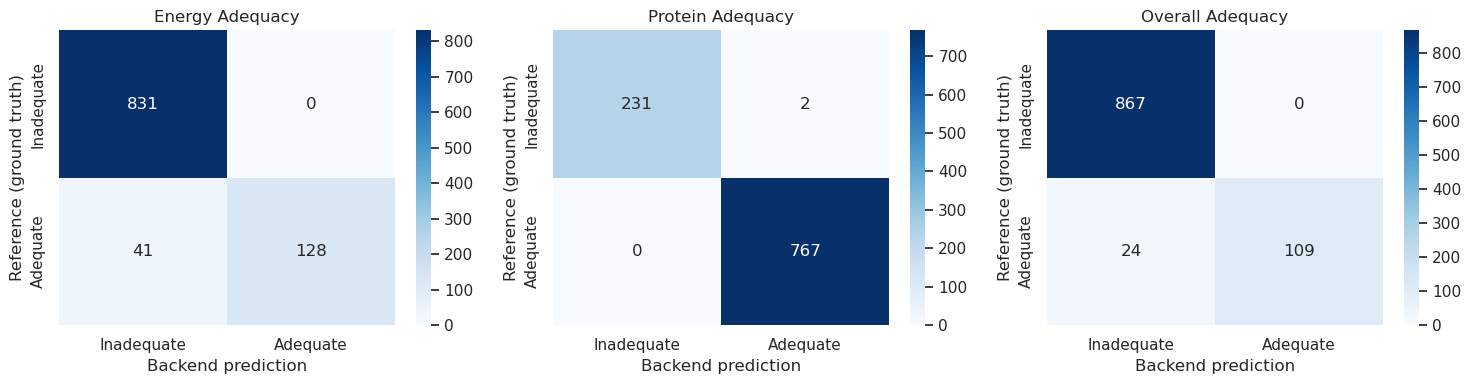

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [
    ("true_energy_adequate", "pred_energy_adequate", "Energy Adequacy"),
    ("true_protein_adequate", "pred_protein_adequate", "Protein Adequacy"),
    ("true_overall_adequate", "pred_overall_adequate", "Overall Adequacy"),
]
for ax, (t, p, title) in zip(axes, pairs):
    cm = confusion_matrix(eval_df[t], eval_df[p])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Inadequate", "Adequate"], yticklabels=["Inadequate", "Adequate"])
    ax.set_title(title)
    ax.set_xlabel("Backend prediction")
    ax.set_ylabel("Reference (ground truth)")
plt.tight_layout()
plt.show()


## 6. Regression sanity-check: backend BMR/TDEE vs. reference values

Both the backend and the dataset's reference column use a Mifflin-St Jeor style
formula independently, so this quantifies how closely they agree in absolute terms
(MAE, RMSE, R²) — a useful complement to the binary adequacy metrics above.


In [8]:
for pred_col, true_col, label in [
    ("backend_bmr", "bmr_kcal", "BMR (kcal)"),
    ("backend_tdee", "tdee_kcal", "TDEE (kcal)"),
]:
    mae = mean_absolute_error(eval_df[true_col], eval_df[pred_col])
    rmse = np.sqrt(mean_squared_error(eval_df[true_col], eval_df[pred_col]))
    r2 = r2_score(eval_df[true_col], eval_df[pred_col])
    print(f"--- {label} ---")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R^2 : {r2:.4f}\n")


--- BMR (kcal) ---
MAE : 0.24
RMSE: 0.29
R^2 : 1.0000

--- TDEE (kcal) ---
MAE : 180.77
RMSE: 357.36
R^2 : 0.2923



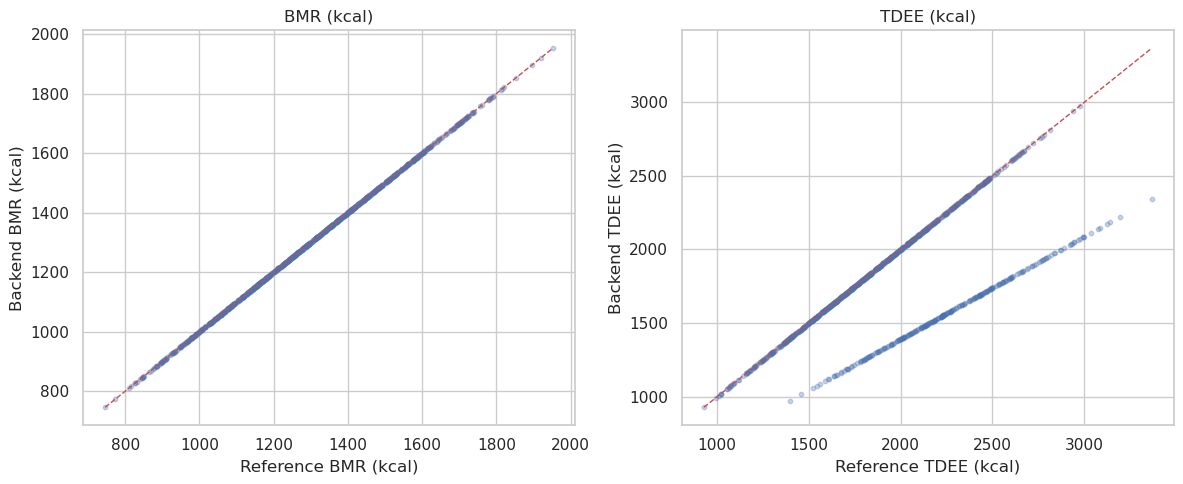

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (pred_col, true_col, label) in zip(axes, [
    ("backend_bmr", "bmr_kcal", "BMR (kcal)"),
    ("backend_tdee", "tdee_kcal", "TDEE (kcal)"),
]):
    ax.scatter(eval_df[true_col], eval_df[pred_col], alpha=0.3, s=10)
    lims = [eval_df[[true_col, pred_col]].min().min(), eval_df[[true_col, pred_col]].max().max()]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_xlabel(f"Reference {label}")
    ax.set_ylabel(f"Backend {label}")
    ax.set_title(label)
plt.tight_layout()
plt.show()


## 7. Medical Suitability Decision Tree — classification evaluation

`core.decision_tree` filters foods out of a meal plan for users with Hypertension or
Diabetes. Its ground-truth labels come from the documented WHO sodium / ADA sugar
thresholds (`decision_tree.build_training_data`); we recreate those labels for every
food in `food_table_clean.csv` and compare them against the already-trained model's
own predictions (`core/ml_artifacts/decision_tree.joblib`, loaded via
`decision_tree.get_model()`).


In [10]:
# food_table_clean.csv uses `calories`/`protein_g`/etc. columns that match the
# model's expected feature names directly.
foods_renamed = foods.rename(columns={"food_name": "name"})

labelled = decision_tree.build_training_data(foods_renamed)
X_dt = labelled[decision_tree.FEATURE_COLS]
y_true_dt = labelled["suitable"]

model = decision_tree.get_model()
y_pred_dt = model.predict(X_dt)

dt_metrics = report_metrics(y_true_dt, y_pred_dt, "Medical Suitability Decision Tree")


--- Medical Suitability Decision Tree ---
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

              precision    recall  f1-score   support

  Inadequate       1.00      1.00      1.00        27
    Adequate       1.00      1.00      1.00       423

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450



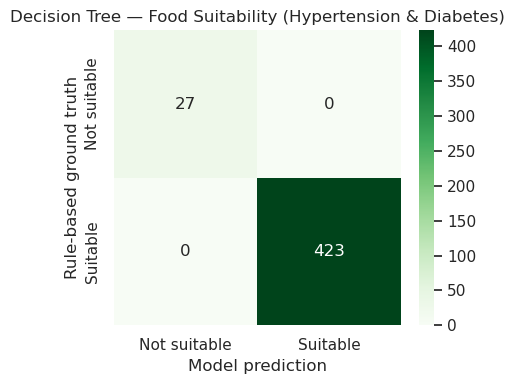

In [11]:
cm_dt = confusion_matrix(y_true_dt, y_pred_dt)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Not suitable", "Suitable"], yticklabels=["Not suitable", "Suitable"])
plt.xlabel("Model prediction")
plt.ylabel("Rule-based ground truth")
plt.title("Decision Tree — Food Suitability (Hypertension & Diabetes)")
plt.tight_layout()
plt.show()


## 8. Summary

In [12]:
summary = pd.DataFrame(results + [dt_metrics]).set_index("label")
summary = summary.round(4)
summary


,accuracy,precision,recall,f1
label,,,,
Energy (Calorie) Adequacy,0.959,1.0000,0.7574,0.8620
Protein Adequacy,0.998,0.9974,1.0000,0.9987
Overall Nutritional Adequacy,0.976,1.0000,0.8195,0.9008
Medical Suitability Decision Tree,1.000,1.0000,1.0000,1.0000


In [13]:
summary.to_csv("evaluation_summary.csv")
print("Saved evaluation_summary.csv")
summary


Saved evaluation_summary.csv


,accuracy,precision,recall,f1
label,,,,
Energy (Calorie) Adequacy,0.959,1.0000,0.7574,0.8620
Protein Adequacy,0.998,0.9974,1.0000,0.9987
Overall Nutritional Adequacy,0.976,1.0000,0.8195,0.9008
Medical Suitability Decision Tree,1.000,1.0000,1.0000,1.0000
